======================================================================                 ** TELCO Customer Churn **
============================================================================================================================================

  ========================================================================================================================================
   ANALYSTLAB Africa Consulting - Week 1
   ===================================================================
   

In [ ]:
## Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

1:Chargement des données
==============================================================================

In [ ]:
# ==================== Chargement des données ===============================================
df = pd.read_csv ('WA_Fn-UseC_-Telco-Customer-Churn (1).csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


2:Vue d'ensemble des données
====================================================================

In [ ]:

print("Dimensions:",df.shape)
print(df.info)
print(df.dtypes)

Dimensions: (7043, 21)
<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  \
0              No  No phone servic

 2.1:valeurs manquantes
 =====================================================

In [ ]:

missing = df.isnull().sum()
print(missing[missing > 0])


Series([], dtype: int64)


2.2: Doublons et statistiques descriptives
=================================================

In [ ]:

print("Doublons :", df.duplicated().sum())
print(df.describe(include='number'))
print(df.describe(include='object'))

for col in df.select_dtypes(include='object').columns:
    print(f"--- {col} ---")
    print(df[col].value_counts())


Doublons : 0
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000
        customerID gender Partner Dependents PhoneService MultipleLines  \
count         7043   7043    7043       7043         7043          7043   
unique        7043      2       2          2            2             3   
top     3186-AJIEK   Male      No         No          Yes            No   
freq             1   3555    3641       4933         6361          3390   

       InternetService OnlineSecurity OnlineBackup DeviceProtection  \
count             7043           7043         7043             7043   
unique             

======================================================================
======================================================================
Après l'interrogation des données, on remarque que notre Dataset ne contient pas de doublons ,

Mais que la colonne Totalcharges n'est pas du bon type donc nous allons devoir le convertir en float et rempacer les chaines de caractère vide  par 0 car quand la tenure est nulle le totalcharges l'est aussi.
Nous remarquons aussi No phone service dans la colonne mutiple line que nous devons transformer en No simple de même pour No internet service dans les colonnes concernées


--After inspecting the data, we note that our dataset does not contain any duplicates. However, the TotalCharges column is not of the correct type, so we will need to convert it to float and replace the empty string values with 0, since when tenure is zero, TotalCharges is also zero. We also notice "No phone service" in the MultipleLines column, which we need to transform into a simple "No", and likewise for "No internet service" in the columns concerned


3.Nettoyage et Preparation des données
=====================================================================

**Conversion de Total numérique en type Float**

In [ ]:
# Remplaçons les chaînes de caractères vides par des NaN
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

# Convertissons la colonne 'TotalCharges' en type numérique (float)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remplaçons les valeurs manquantes (NaN) avec 0.0, car il s'agit probablement de nouveaux clients sans frais (Total-charges)
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# Vérification le type de données après la conversion
print(df['TotalCharges'].dtype)

# Vérifions s'il reste des valeurs manquantes dans TotalCharges
print(f"Nombre de NaN dans 'TotalCharges' après traitement : {df['TotalCharges'].isnull().sum()}")

df.info()

float64
Nombre de NaN dans 'TotalCharges' après traitement : 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non

3.1: Remplacement des valeurs
=========================================

In [ ]:
## Remplacement de NO internet service par NO et de No phone service par No
internet_dependent_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                            'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in internet_dependent_cols:
    df[col] = df[col].replace('No internet service', 'No')

print("Vérification des colonnes dépendantes d'internet après remplacement:")
for col in internet_dependent_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print("\n")

# Remplacer 'No phone service' par 'No' dans la colonne 'MultipleLines'
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

print("Vérification de la colonne MultipleLines après remplacement:")
print(f"--- MultipleLines ---")
print(df['MultipleLines'].value_counts())

Vérification des colonnes dépendantes d'internet après remplacement:
--- OnlineSecurity ---
OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64


--- OnlineBackup ---
OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64


--- DeviceProtection ---
DeviceProtection
No     4621
Yes    2422
Name: count, dtype: int64


--- TechSupport ---
TechSupport
No     4999
Yes    2044
Name: count, dtype: int64


--- StreamingTV ---
StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64


--- StreamingMovies ---
StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64


Vérification de la colonne MultipleLines après remplacement:
--- MultipleLines ---
MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64


In [ ]:
## Création d'une nouvelle colonne Tenure-Mois
def tenure_bucket(months):
    if months <= 12: return "0-12 mois"
    elif months <= 24: return "13-24 mois"
    elif months <= 48: return "25-48 mois"
    else: return "49-72 mois"

df['tenure_Mois'] = df['tenure'].apply(tenure_bucket)

## Ordre logique des mois
tenure_order = ["0-12 mois", "13-24 mois", "25-48 mois", "49-72 mois"]
df['tenure_Mois'] = pd.Categorical(df['tenure_Mois'], categories=tenure_order, ordered=True)

# Afficher la répartition des nouvelles catégories
print(df['tenure_Mois'].value_counts())

tenure_Mois
49-72 mois    2239
0-12 mois     2186
25-48 mois    1594
13-24 mois    1024
Name: count, dtype: int64


4:Representation des graphiques
=====================================================================

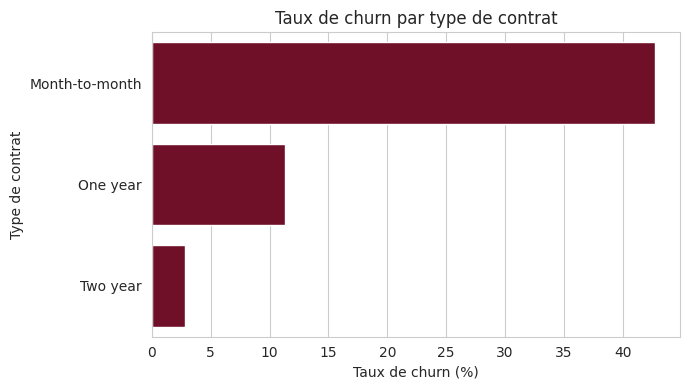

Segment le plus à risque : Month-to-month (42.7%)


In [ ]:
## Contract x churn (%)
rate_contract = (
    df.groupby('Contract')['Churn']
    .apply(lambda s: (s == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))
sns.barplot(x=rate_contract.values, y=rate_contract.index, color='#800020') # Rouge bordeaux
plt.xlabel("Taux de churn (%)")
plt.ylabel("Type de contrat")
plt.title("Taux de churn par type de contrat")
plt.tight_layout()
plt.savefig('bar_contract_churn_bordeaux.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Segment le plus à risque : {rate_contract.index[0]} ({rate_contract.iloc[0]:.1f}%)")

**Interprétation du Churn par Type de Contrat**
============================================================================================================================================
Ce graphique montre clairement que les clients ayant un contrat court,
se désabonnent nettement plus (42,7% de taux de churn sur ce segment)

Plus le contrat est long (One year, Two year), plus le taux de churn (départ) est bas :
respectivement 11,3% et 2,8%

Ce facteur est d'autant plus critique que 88,6% de tous les clients perdus proviennent
du segment Month-to-month et la quasi-totalité du problème de désabonnement de l'entreprise est concentrée sur ce seul type de contrat.

**La racine cause probable est donc un engagement contractuel faible qui facilite le départ :
sans engagement de durée, le client n'a aucune contrainte à quitter l'entreprise à tout moment**

--This chart clearly shows that customers with a short-term contract  month-to-month, churn significantly more (42.7% churn rate for this segment).

The longer the contract (One year, Two year), the lower the churn rate: 11.3% and 2.8% respectively.

This factor is even more critical given that 88.6% of all lost customers come from the "Month-to-month" segment — the vast majority of the company's churn problem is concentrated in this single contract type.

**The probable root cause is therefore a weak contractual commitment that facilitates departure: without a fixed-term commitment, the customer has no constraint preventing them from leaving the company at any time**


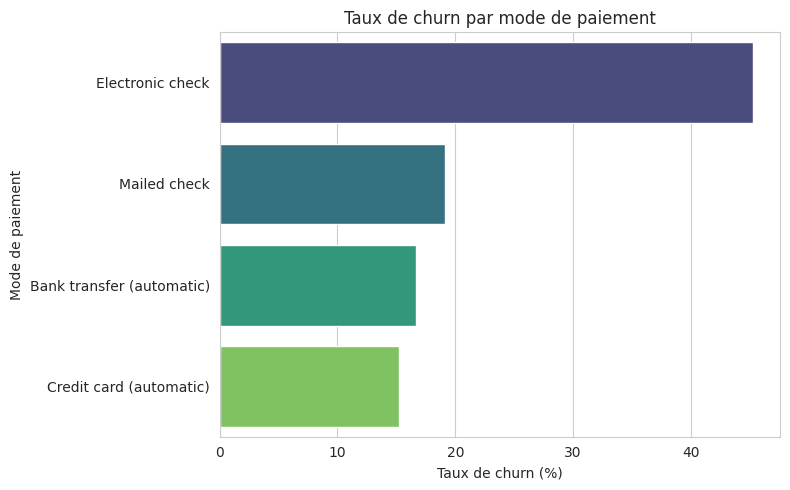

Le mode de paiement le plus associé au churn est : Electronic check (45.3%)


In [ ]:
## PaymentMethod x churn (%)
rate_payment = (
    df.groupby('PaymentMethod')['Churn']
    .apply(lambda s: (s == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=rate_payment.values, y=rate_payment.index, palette='viridis', hue=rate_payment.index, legend=False)
plt.xlabel("Taux de churn (%)")
plt.ylabel("Mode de paiement")
plt.title("Taux de churn par mode de paiement")
plt.tight_layout()
plt.savefig('bar_payment_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Le mode de paiement le plus associé au churn est : {rate_payment.index[0]} ({rate_payment.iloc[0]:.1f}%)")

**Interpretation Churn x mode de paiement**
============================================================================================================================================
**le graphique montre clairement que le moyen de paiement le plus à risque pour le churn est le check électronique et le taux élevé de désabonnement peut se justifier par le fait que les clients utilisant le check electronique ont la possibilité de reconsidérer leur abonnement chaque mois ou de laisser alors que ceux par des paiements automatiques restent activent même sans réaction ce qui réduit le risque de départ chez eux**

-- The chart clearly shows that the payment method most at risk for churn is electronic check, and the high churn rate can be explained by the fact that customers using electronic check have the option to reconsider their subscription every month or
let it lapse,hereas customers on automatic payment methods remain active even without taking any action, which reduces their risk of leaving

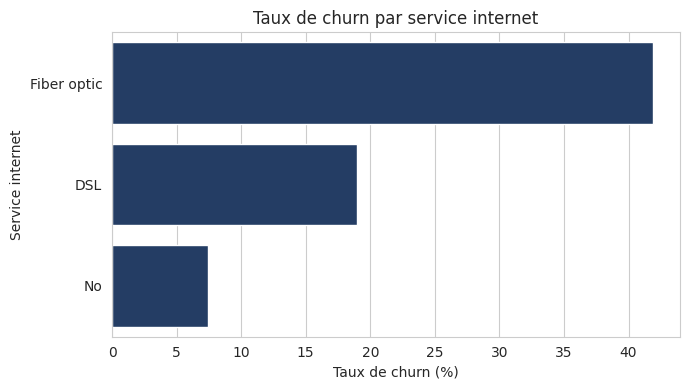

Segment le plus à risque : Fiber optic (41.9%)


In [ ]:
## Internet service x churn
rate_internet = (
    df.groupby('InternetService')['Churn']
    .apply(lambda s: (s == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))
sns.barplot(x=rate_internet.values, y=rate_internet.index, color='#1a3a6e')
plt.xlabel("Taux de churn (%)")
plt.ylabel("Service internet")
plt.title("Taux de churn par service internet")
plt.tight_layout()
plt.savefig('bar_internet_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Segment le plus à risque : {rate_internet.index[0]} ({rate_internet.iloc[0]:.1f}%)")

**Interpretation de churn x service internet**
============================================================================================================================================
Ce graphique montre que la racine de désabonnement (churn) est plus lié à la Fibre optic
Cela peut s'expliquer par peut être le coût élevé par rapport aux autres et peut-être les soucis techniques n'étant peut-être pas à la hauteur du coût .
De plus, plus le service est élevé plus le désabonnement est élevé

--This chart shows that churn is most strongly linked to the Fiber optic service.

This can be explained by, perhaps, its higher cost compared to other services,
and possibly technical issues that don't quite match up to that cost.

Moreover, the more advanced the service, the higher the churn rate


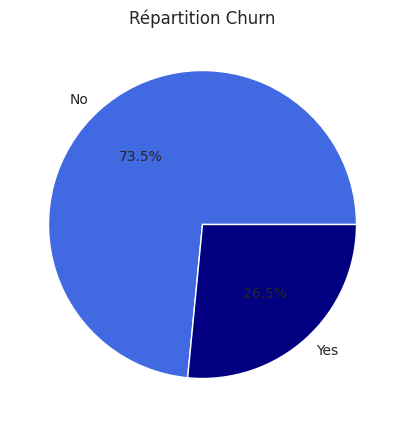

In [ ]:
## Répartition globale du churn
plt.figure(figsize=(5, 5))
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#4169E1', '#000080']) # Nuances de bleu foncé (Royal Blue et Navy)
plt.title("Répartition Churn")
plt.ylabel('')
plt.show()

**Interpretation du graphique**
============================================================================================================================================
 Ce graphique montre que 26.5% des clients se désabonnent. Bien que minoritaire, ce pourcentage représente une part non négligeable de la clientèle. Près d'un quart des clients partent, ce qui met en évidence l'importance de comprendre les raisons de ce désabonnement afin de mettre en place des stratégies de rétention efficaces

 --This chart shows that 26.5% of customers churn. Although a minority, this percentage
represents a significant share of the customer base. Nearly a quarter of customers
leave, which highlights the importance of understanding the reasons behind this churn
in order to implement effective retention strategie

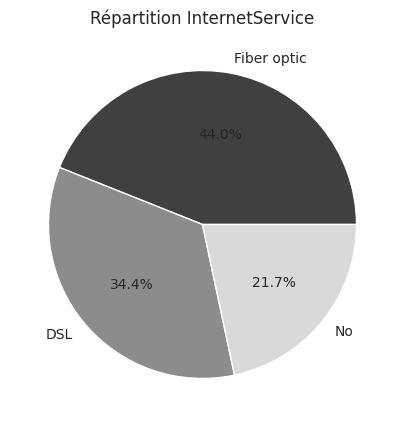

In [ ]:
plt.figure(figsize=(5, 5))
df['InternetService'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#404040', '#8C8C8C', '#D9D9D9'])
plt.title("Répartition InternetService")
plt.ylabel('')
plt.show()

Interpretation de le répartion Internet service
============================================================================================================================================
Ce graphique montre que la fibre optic n'est pas seulemnt le fibre avec le taux de churn élévé mais aussi c'est le segment avec la majorité des clients ,

cela veut dire que le plus gros problème de rétention de l'entreprise touche son plus gros segment de clients et  c'est un problème central

--This chart shows that Fiber optic is not only the segment with the highest churn rate but also the segment with the largest share of customers

This means that the company's biggest retention problem affects its largest customer segment making it a central issue rather than a marginal one


4.1: Tableau comparatif des impacts
=====================================================

In [ ]:

def impact_table(variable):
    # Nombre total de clients
    total_clients = df.shape[0]
    # Nombre total de churns
    total_churns = df[df['Churn'] == 'Yes'].shape[0]

    # Calcul du nombre de clients par segment
    nb_clients_segment = df.groupby(variable).size().rename('Nb_clients')

    # Calcul du taux de churn par segment
    churn_rate_segment = (
        df.groupby(variable)['Churn']
        .apply(lambda s: (s == 'Yes').mean() * 100)
        .rename('Taux_churn_%')
    )

    # Calcul de la part des churns totaux par segment
    part_churns_totaux_segment = (
        df[df['Churn'] == 'Yes'].groupby(variable).size() / total_churns * 100
    ).rename('Part_des_churns_totaux_%')

    # Combiner les résultats dans un DataFrame
    impact_df = pd.DataFrame({
        'Nb_clients': nb_clients_segment,
        'Taux_churn_%': churn_rate_segment,
        'Part_des_churns_totaux_%': part_churns_totaux_segment
    })

    return impact_df

all_impacts = []
for var in ['Contract', 'PaymentMethod', 'InternetService']:
    t = impact_table(var).reset_index()
    t.columns = ['Segment', 'Nb_clients', 'Taux_churn_%', 'Part_des_churns_totaux_%']
    t.insert(0, 'Variable', var)
    all_impacts.append(t)

impact_summary = pd.concat(all_impacts, ignore_index=True)
impact_summary.to_csv('impact_summary.csv', index=False)
print("Voici le tableau comparatif des impacts :")
display(impact_summary)

Voici le tableau comparatif des impacts :


,Variable,Segment,Nb_clients,Taux_churn_%,Part_des_churns_totaux_%
0,Contract,Month-to-month,3875,42.709677,88.550027
1,Contract,One year,1473,11.269518,8.881755
2,Contract,Two year,1695,2.831858,2.568218
3,PaymentMethod,Bank transfer (automatic),1544,16.709845,13.804173
4,PaymentMethod,Credit card (automatic),1522,15.243101,12.413055
5,PaymentMethod,Electronic check,2365,45.285412,57.303371
6,PaymentMethod,Mailed check,1612,19.106700,16.479401
7,InternetService,DSL,2421,18.959108,24.558587
8,InternetService,Fiber optic,3096,41.892765,69.395399
9,InternetService,No,1526,7.404980,6.046014


Les profils à risque
========================================================

In [ ]:
## Déterminons les profils à risque
profil_risque = df[
    (df['Contract'] == 'Month-to-month') &
    (df['PaymentMethod'] == 'Electronic check') &
    (df['InternetService'] == 'Fiber optic')
]
taux_churn_profil = (profil_risque['Churn'] == 'Yes').mean() * 100
print(f"Nombre de clients cumulant les 3 facteurs à risque : {len(profil_risque)}")
print(f"Taux de churn de ce profil combiné : {taux_churn_profil:.1f}%")

Nombre de clients cumulant les 3 facteurs à risque : 1307
Taux de churn de ce profil combiné : 60.4%


    ==========================================================
  Le tableau comparatif et l'analyse des profils à risque montrent que le type de
    contrat est le facteur le plus dominant dans la perte de clients : 88,6% de tous les clients perdus proviennent du segment "Month-to-month". Ce risque s'aggrave encore lorsqu'il se cumule avec d'autres facteurs : les clients réunissant les trois profils à risque (contrat mensuel, paiement par chèque électronique, service Fiber optic) , soit 18,6% de la base ,atteignent un taux de churn de 60,4%,
    plus du double de la moyenne globale (26,5%)
     ==========================================================

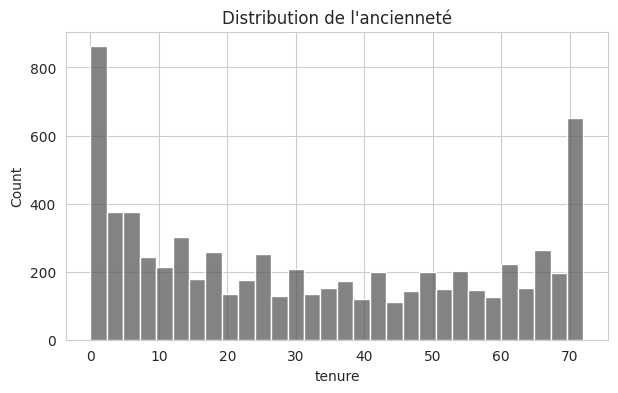

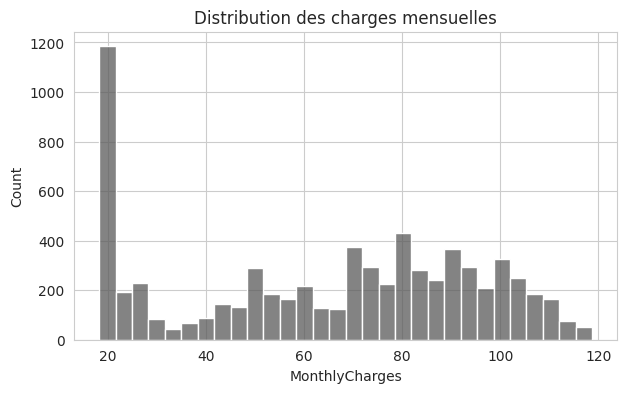

In [ ]:
## Hustogrammes
plt.figure(figsize=(7, 4))
sns.histplot(df['tenure'], bins=30, color='#595959')
plt.title("Distribution de l'ancienneté")
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(df['MonthlyCharges'], bins=30, color='#595959')
plt.title("Distribution des charges mensuelles")
plt.show()

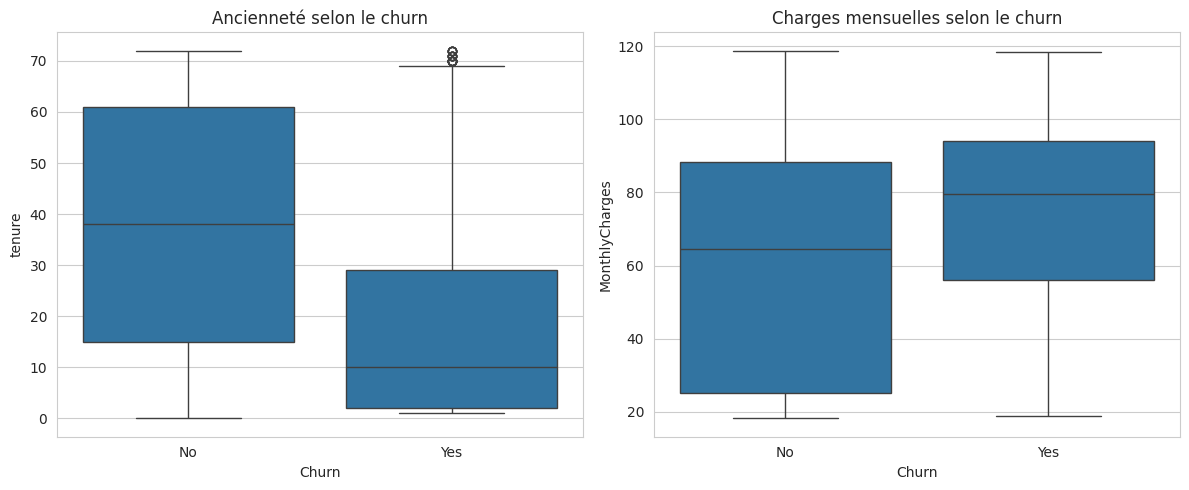

In [ ]:
##Boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0])
axes[0].set_title("Ancienneté selon le churn")
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1])
axes[1].set_title("Charges mensuelles selon le churn")
plt.tight_layout()
plt.show()

**Interpretation du résultat**
============================================================================================================================================
ce graphique montre que les
-Clients fidèles (No) ont une médiane à 38 mois, boîte entre 15 et 61 mois et les
-Clients partis (Yes) ont médiane à seulement 10 mois, boîte entre 2 et 29 mois — nettement plus basse et plus resserrée vers le bas
 **Et cela confirme le poids du contrat mensuel comme les autres graphiques**

 --This chart shows that loyal customers (No) have a median tenure of 38 months while churned customers (Yes) have a median tenure of only 10 months (box between 2 and 29 months) noticeably lower and more concentrated toward the bottom.

This confirms that churn mostly occurs early in the customer relationship, which aligns with the weight of month-to-month contracts observed in the other charts:
a recent customer is also statistically more likely to still be on a month-to-month contract which explains why the two factors low tenure and short-term contract often go hand in hand in the profile of customers who leave


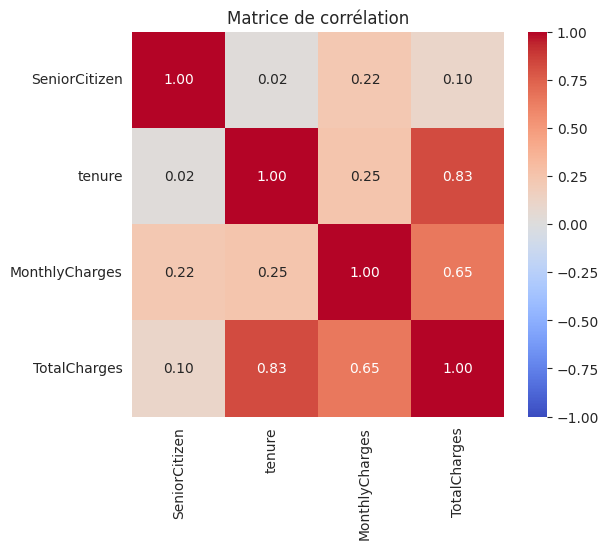

In [ ]:
## Heatmap
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Matrice de corrélation")
plt.show()

**Interpretation du résultat **
============================================================================================================================================
Ce graphique montre que
MonthlyCharges x TotalCharges montre 0,65:une corrélation forte mais plus modérée, car TotalCharges dépend aussi de l'ancienneté

 La tenure x MonthlyCharges montre 0,25 : unecorrélation faible : l'ancienneté d'un client n'est pas vraiment liée au tarif qu'il paie

SeniorCitizen montre une corrélation faible avec tout (0,02 à 0,22) — être un client senior n'est pas fortement lié à l'ancienneté ou aux charges dans ce dataset

--This chart shows that: MonthlyCharges x TotalCharges shows a correlation of 0.65: a strong but more moderate correlation, since TotalCharges also depends on tenure

tenure x MonthlyCharges shows a correlation of 0.25: a weak correlation : a customer's tenure is not strongly related to the rate they pay

SeniorCitizen shows weak correlations across the board (0.02 to 0.22)  being : a senior customer is not strongly linked to tenure or charges in this dataset


====================================================================
**Keys Insights**
======================================================================
    --The contract type is the dominant facteur of churn
    88.6% of customers come from Month-to-Month segmeent and the churn rate is 42.7% compared to 11.3% for One-year and to 2.8% for two-year
    --The payement Method is the second factor risk of churn with 45.3% for electronic-check payement compared to others
    --The Fiber optic is the most fragile segment because it represents 44% of the customer base while also carrying the highest churn rate (41.9%)
    --Risk factors: customers combining the three risk represents only 18.6 % of the customer base
    --Retention is won or lost in the first year because Churned customers have a median tenure of just 10 months, versus 38 months for retained customer



**Business Risks**
=====================================================================
    -Concentrated exposure on a single high-risk profile
    Nearly half of all churn stems from a relatively small, well-defined customer profile (month-to-month + electronic check + Fiber optic) Without targeted intervention.This concentration leaves the business exposed to continued predictable revenue loss

    -High churn poses a significant customer retention risk

    -Churned customers pay a higher median monthly charge than retained customersand it means that the company is  losing its highest-value customers rather than its lowest-value ones.


**Business opportunities and Recommandations**
======================================================================
     --Contract conversion   
    Because contract type is the strongest churn driver moving even a small share of month‑to‑month customers to annual contracts would likely have the biggest impact on reducing churn
    --Switching customers from electronic check to automatic payment methods (bank transfer, credit card) is a simple, low‑cost action that directly reduces one of the main churn drivers without changing the service itself
    --Since churn is concentrated in the first months of the relationship, a structured onboarding and early‑loyalty program for new customers could stop churn before it happens, instead of reacting afterward
    --Identify and prioritize customers who combine these three risk factors with a combined retention offer: incentive to switch to an annual contract + migration to automatic payment, before a service issue pushes them to leave
    --Prioritize a campaign to convert month‑to‑month contracts into annual contracts through discounts or added benefits, as this is the lever with the highest potential impact on the overall churn rate
